# Sensor Analysis, Analysis

- **Question**: Are any sensors drifting or behaving abnormally over time?
- **Data**: Synthetic sensor telemtry (user-generated)
- **Unit of Analysis**: 1 row = 1 sensor reading at a timestamp
- **Output**: Cleaned dataset + plots + engine memo 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [2]:
#synthetic Aersopace-style dataset

rng = np.random.default_rng(7)


n_minutes = 24 * 60 # minutes in one day
t = pd.date_range('2026-01-01', periods = n_minutes, freq="min")


#simulate 3 sensors: two stable, one drifing
sensor_A = 20 + rng.normal(0, 0.2, size=n_minutes)   #stable temp-ish
sensor_B = 101.3 + rng.normal(0, 0.05, size = n_minutes) # stable presuure-is
sensor_C = 5 + 0.002*np.arange(n_minutes) + rng.normal(0, 0.15, size=n_minutes) #slow drift

df = pd.DataFrame({
    'timestamp': t,
    'temp_A': sensor_A,
    'press_B': sensor_B,
    'vib_C': sensor_C
})

#Inject Missingness & a small anomaly burst
missing_idx = rng.choice(n_minutes, size=60, replace=False)
df.loc[missing_idx, 'vib_C'] += 1.5  #anomaly window






*I'm generating telemetry-like time series with known behaviors so I can practice the full pipeline end-to-end*

In [3]:
#convert types & set time index

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1440 entries, 2026-01-01 00:00:00 to 2026-01-01 23:59:00
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   temp_A   1440 non-null   float64
 1   press_B  1440 non-null   float64
 2   vib_C    1440 non-null   float64
dtypes: float64(3)
memory usage: 45.0 KB


In [4]:
#data quality checks
df.isna().mean().sort_values(ascending=False)
df.describe().T
# misisngness rates? ranges- anything physically impossible? std/mean sifts hint at drift


,count,mean,std,min,25%,50%,75%,max
temp_A,1440.0,19.988593,0.195338,19.349712,19.856944,19.987714,20.121188,20.565780
press_B,1440.0,101.300028,0.050172,101.116946,101.264245,101.299025,101.334621,101.457407
vib_C,1440.0,6.501905,0.881627,4.617920,5.751832,6.497072,7.238218,9.364498


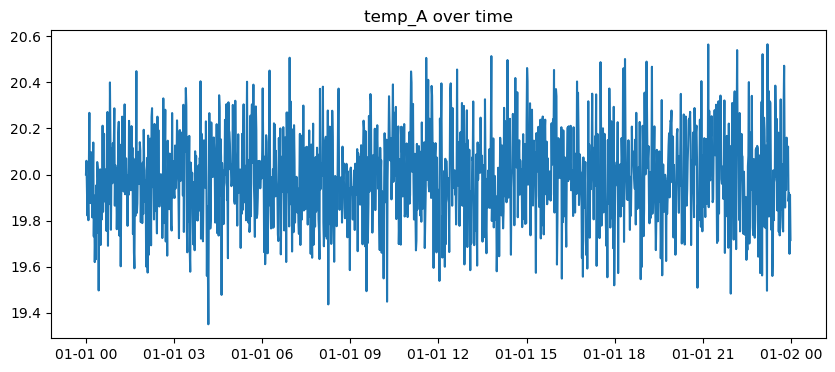

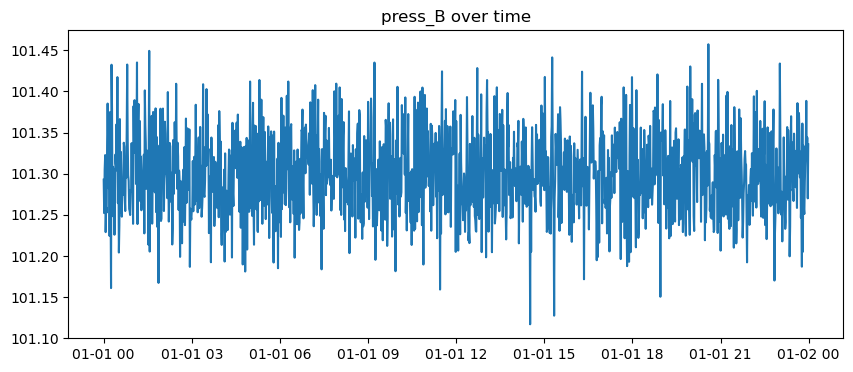

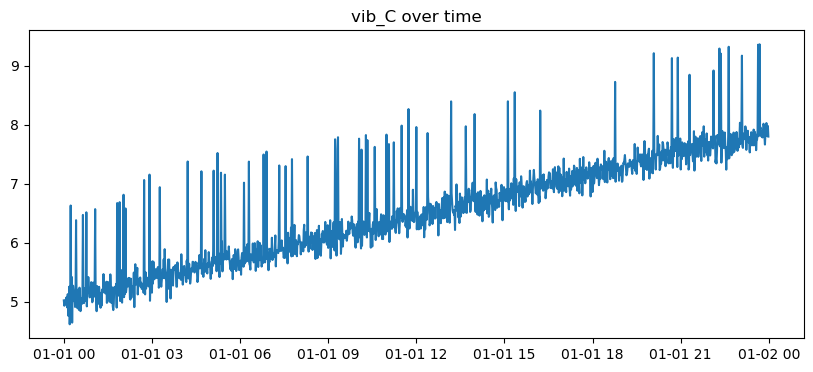

In [5]:
#plot of the raw signals pre-modeling

plt.figure(figsize=(10,4))
plt.plot(df.index, df['temp_A'])
plt.title('temp_A over time')
plt.show()

plt.figure(figsize=(10,4))
plt.plot(df.index, df['press_B'])
plt.title('press_B over time')
plt.show()

plt.figure(figsize=(10,4))
plt.plot(df.index, df['vib_C'])
plt.title('vib_C over time')
plt.show()

before any stats, I visualize each channel to identify obvious drift, step changes, missing segments, or anomalies

In [6]:
#feature engineering - rolling stats

window = 30 #30 minutes

features = pd.DataFrame(index=df.index)
features['vib_C'] = df['vib_C']
features['vib_C_roll_mean'] = df['vib_C'].rolling(window=window, min_periods=10).mean()
features['vib_C_roll_std'] = df['vib_C'].rolling(window=window, min_periods=10).std()
features['vib_C_diff_1'] = df['vib_C'].diff(1)

features.head(15)


,vib_C,vib_C_roll_mean,vib_C_roll_std,vib_C_diff_1
timestamp,,,,
2026-01-01 00:00:00,5.022990,NaN,NaN,NaN
2026-01-01 00:01:00,4.932522,NaN,NaN,-0.090468
2026-01-01 00:02:00,4.989603,NaN,NaN,0.057081
2026-01-01 00:03:00,4.996692,NaN,NaN,0.007089
2026-01-01 00:04:00,5.036668,NaN,NaN,0.039976
2026-01-01 00:05:00,5.070209,NaN,NaN,0.033541
2026-01-01 00:06:00,4.935666,NaN,NaN,-0.134542
2026-01-01 00:07:00,4.902884,NaN,NaN,-0.032782
2026-01-01 00:08:00,5.128121,NaN,NaN,0.225237


**Rolling** converts raw readings into behavior (trend + volatility)

In [7]:
#drift/anomaly score

baseline = features['vib_C_roll_mean']
spread = features['vib_C_roll_std']

features['vib_C_z'] = (features['vib_C'] - baseline) / spread

features['vib_C_z'].describe()

count    1431.000000
mean        0.100088
std         0.973686
min        -2.348000
25%        -0.388174
50%        -0.077542
75%         0.321599
max         4.957238
Name: vib_C_z, dtype: float64

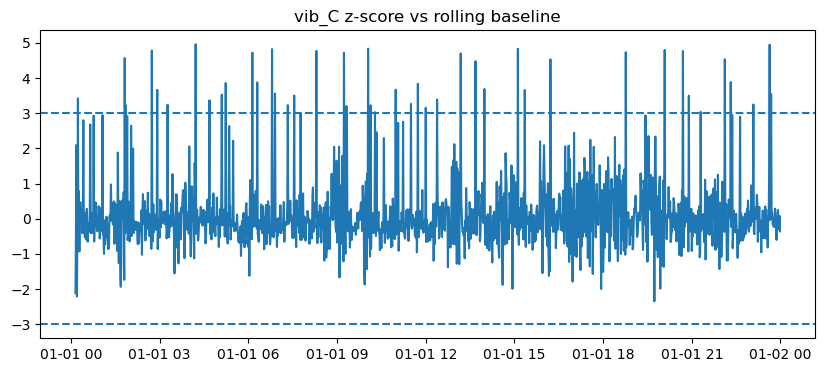

In [8]:
#ship it (plot it)

plt.figure(figsize=(10,4))
plt.plot(features.index, features['vib_C_z'])
plt.axhline(3, linestyle='--')
plt.axhline(-3, linestyle='--')
plt.title('vib_C z-score vs rolling baseline')
plt.show()


I'm using a rolling mean/std as a local baseline, then converting deviation into a standardized score so thresholds are interpretable. 

## Engineering Memo:

**Question** 
Are there indications of sensor drift or anmoalous behavior in the vibration signal over time?

**Data**
Synthetic Telemetry data representing per-minute sensor readings over a 24-hour period. The dataset includes:
- one stable tempurature-like signal
- one stable pressure-like signal
- one vibration-like signal with slow drift, injected missingness, and a short anomaly burst

Each row represents a single timestampes senor observation

**Checks Performed**
- verified timestamp integriyu and sorted time index
- Assessed missingness rates by column
- Reviewed summary statistics for range and variability
- Visualized raw time-series signals to inspect trends, drift, and anomalies
- Computed rolling mean and rolling standrd deviation using a 30-minute window with a minimum of 10 observations

**Findings**
- The vibration signal (vib_C) exhibits a gradual upward drift over time, consitstent with sensor bias accumulation rather than random fluctuation.
- A localized anomaly window is visible as a short-lived deviation from the rolling baseline.
- Rolling statistics are undefined during the initial portion of the series due to insufficient historical data, which is expected given the minimum window requirement
- After the window is established, rolling mean and standrd deviation provide a stable local baseline for assessing deviations.
- Standardized deviations (z-scores) relative to the rolling baseline highlight the anomaly window clearly without triggering excessive false positives elsewhere.

**Interpretation**
The observed behavior is consistent with a sensor exhibiting slow drift plus short-duraion anomalous events, rather than a pure random walk

Treating early NaN values as a warm-up perioud preserves statistical validity and avoids introducing bias from undersupported estimates.

**Next Steps**
- Evaluate imputation strategies for missing vibration readings prior to rolling feature computation.
- Extend the approach to multiple sensors and assess cross-sensor consistency.
- Reframe the rolling-baseline logic as a state space model to explicitly seperate latent drift from measuremet noise.

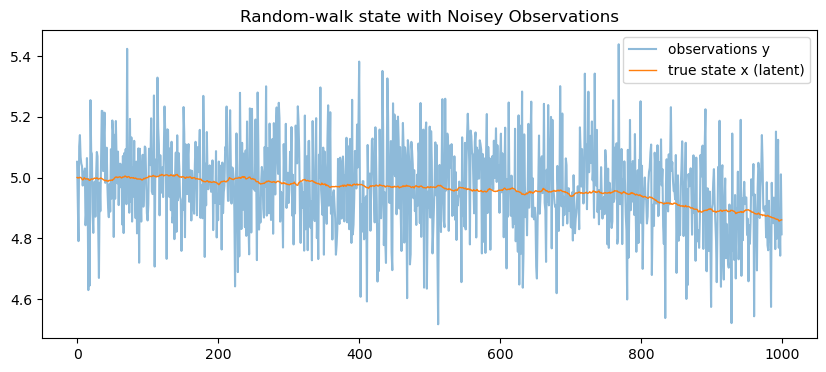

In [38]:
## Q- process noise variance (how fast the true state can wander)
## R- meaurement noise variance (how noise the sensor is)

n = 1000
Q_true = 0.002**2 # process noise variance
R_true = 0.15**2 #measurement noise variance

# latent state (random walk)
w = rng.normal(0, np.sqrt(Q_true), size=n)
x = 5 + np.cumsum(w)

#observations
v = rng.normal(0, np.sqrt(R_true), size=n)
y = x + v

plt.figure(figsize=(10,4))
plt.plot(y, alpha=0.5, label='observations y')
plt.plot(x, linewidth=1, label='true state x (latent)')
plt.title('Random-walk state with Noisey Observations')
plt.legend()
plt.show()

In [39]:
# Kalman form scratch

def kalman_filter_1d(y, Q, R, x0=0.0, P0=1.0):
    """

    1D kalman filter for:
        x_t = x_{t-1} + w_t,    w_t ~N(0, Q)
        y_t = x_t + v_t,        v_t ~N(0, R)

    Returns:
        x_filt: filtered state means
        P_filt: filtered state variances
        k: Kalman gains
    """

    n = len(y)
    x_filt = np.zeros(n)
    P_filt = np.zeros(n)
    innovations = np.zeros(n)
    S_vals = np.zeros(n)

    x_prev = x0
    P_prev = P0

    for t in range(n):
        # 1st- Predict (time update)
        x_pred = x_prev
        P_pred = P_prev + Q

        # Innovation(residual)
        innov = y[t] - x_pred
        S = P_pred + R #innovation variance

        #updat
        K= P_pred / S
        x_new = x_pred + K * innov #state update
        P_new = (1 - K) * P_pred #variance update

        x_filt[t] = x_new
        P_filt[t] = P_new
        innovations[t] = innov
        S_vals[t] = S
        

        x_prev, P_prev = x_new, P_new

    return x_filt, P_filt, innovations, S_vals


In [41]:
x_hat, P_hat, innov, S = kalman_filter_1d(
    y=df['vib_C'].values, 
    Q=Q, 
    R=R, 
    x0=df['vib_C'].iloc[0], 
    P0=1.0
)

#standardize innovations
z_innov = innov / np.sqrt(S)

out = df.copy()
out['x_hat'] = x_hat
out['P_hat'] = P_hat
out['innov'] = innov
out['S'] = S
out['z_innov'] = z_innov

#rolling Z-score interlude
z_roll = features['vib_C_z']


THRESH = 3.0
out["anomaly"] = np.abs(out['z_innov']) > THRESH
out['z_roll'] = z_roll
out['roll_anomaly'] = np.abs(out['z_roll']) > THRESH
out.tail(10)


,temp_A,press_B,vib_C,x_hat,P_hat,innov,S,z_innov,anomaly,z_roll,roll_anomaly
timestamp,,,,,,,,,,,
2026-01-01 23:50:00,19.933135,101.258466,7.981368,7.769955,0.000298,0.214251,0.022802,1.418848,False,0.178989,False
2026-01-01 23:51:00,20.160280,101.251051,7.798132,7.770328,0.000298,0.028177,0.022802,0.186598,False,-0.289343,False
2026-01-01 23:52:00,20.058199,101.290248,7.664733,7.768929,0.000298,-0.105595,0.022802,-0.699291,False,-0.602466,False
2026-01-01 23:53:00,20.055941,101.313321,7.850858,7.770014,0.000298,0.081929,0.022802,0.542563,False,-0.160531,False
2026-01-01 23:54:00,20.121455,101.330605,7.842366,7.770973,0.000298,0.072352,0.022802,0.479143,False,-0.178686,False
2026-01-01 23:55:00,19.884101,101.388582,8.028816,7.774388,0.000298,0.257843,0.022802,1.707535,False,0.248271,False
2026-01-01 23:56:00,19.919126,101.317931,7.807794,7.774830,0.000298,0.033406,0.022802,0.221229,False,-0.301925,False
2026-01-01 23:57:00,19.655751,101.344060,7.835790,7.775638,0.000298,0.060960,0.022802,0.403697,False,-0.248762,False
2026-01-01 23:58:00,19.911626,101.270076,7.979200,7.778334,0.000298,0.203562,0.022802,1.348064,False,0.081031,False


In [42]:
summary = {
    "rows": len(out),
    "missing_vib_C_pct": float(out["vib_C"].isna().mean()),
    "innov_anomaly_count": int(out["anomaly"].sum()),
    "innov_anomaly_rate": float(out["anomaly"].mean()),
    "max_abs_z_innov": float(np.nanmax(np.abs(out["z_innov"]))),

    "roll_anomaly_count": int(out["roll_anomaly"].sum()),
    "roll_anomaly_rate": float(out["roll_anomaly"].mean()),
    "agreement_count": int((out["anomaly"] & out["roll_anomaly"]).sum()),
    "roll_only_count": int((~out["anomaly"] & out["roll_anomaly"]).sum()),
    "innov_only_count": int((out["anomaly"] & ~out["roll_anomaly"]).sum()),
}
summary


{'rows': 1440,
 'missing_vib_C_pct': 0.0,
 'innov_anomaly_count': 70,
 'innov_anomaly_rate': 0.04861111111111111,
 'max_abs_z_innov': 12.951322800641611,
 'roll_anomaly_count': 43,
 'roll_anomaly_rate': 0.029861111111111113,
 'agreement_count': 43,
 'roll_only_count': 0,
 'innov_only_count': 27}

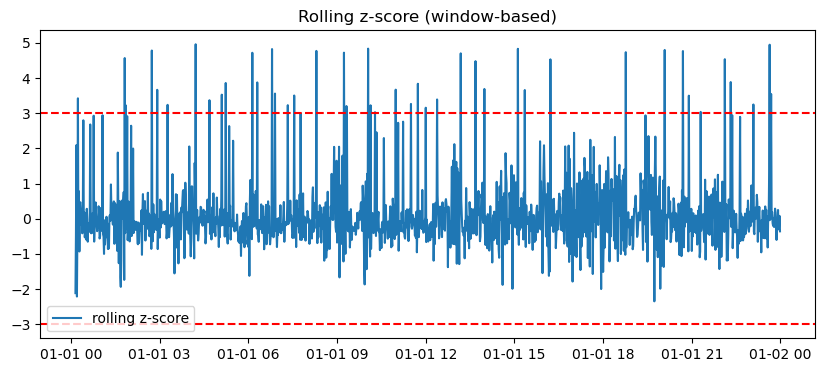

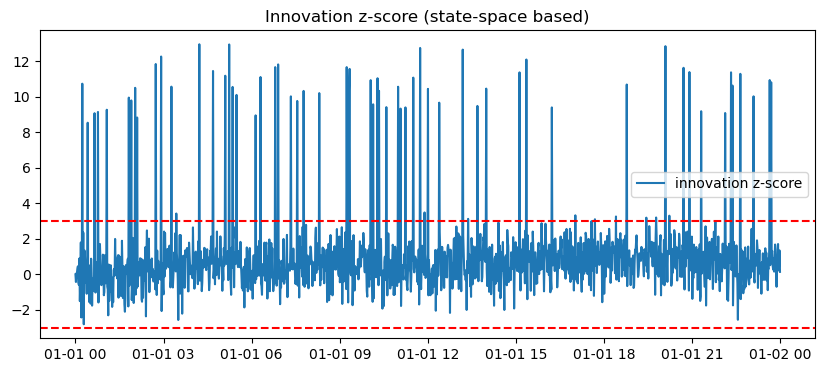

In [46]:
plt.figure(figsize=(10,4))
plt.plot(out.index, out["z_roll"], label="rolling z-score")
plt.axhline(3, linestyle="--", color="red")
plt.axhline(-3, linestyle="--", color="red")
plt.title("Rolling z-score (window-based)")
plt.legend()
plt.show()



## Summary - Rolling vs Innovation Z-Scores

In this exercise, I compared two methods for standradizing deviations in a time series signal: rolling z-scores and innovation z-scores derived from a state-space model.

Rolling z-scores normalize observations relative to a locally estimated mean and variance computed over a fixed window. While useful for quick screening, this approach relies on arbitrary window length choices and implicit stationary assumptions. In physical systems with drift or state persistence, the baseline itself moved with the data, causing threshold crossins to feel reactive and inconsistently meaningful.

Innovation z-scores arise from a state-space formulation in which a latent state represents the system's evoling baseline and uncertainty is explicitly propogated. Standardized innovations measure how inconsistent an observation is with the model's prediction, not just how far it is from recent history. As a result, innoation spikes correspond to violations of assumd system dynamics rather than geneic statistical outliers.

This comparison clarified why rolling z-scores can feel flimsy in physical systems: they contextualize deviation without encoding behavior. Innovation z-scored, by contrast, are grounded in a hypothesis about how the system evolves, making their thresholds interpretable and diagnostic. 